In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [10]:
def calculate_modulus(df, strain_min, strain_max):
    mask = (df['strain'] >= strain_min) & (df['strain'] <= strain_max)
    filtered_data = df[mask]

    x = filtered_data['strain']
    y = filtered_data['stress']

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    r_squared = r_value ** 2

    return slope*1e-3, r_squared

def calculate_poisson(df, time_min, time_max):
    mask = (df['time'] >= time_min) & (df['time'] <= time_max)
    filtered_data = df[mask]

    x = filtered_data['strain_major']
    y = filtered_data['strain_minor']

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    r_squared = r_value ** 2

    return slope*(-1), r_squared

In [11]:
col = ['displacement', 'load']
df_tensile_0 = pd.read_csv('CFUD0_tensile.csv', names=col)
df_tensile_90 = pd.read_csv('CFUD90_tensile.csv', names=col)
df_shear_0 = pd.read_csv('CFUD0_shear.csv', names=col)

col_dic = ['time', 'strain_major', 'strain_minor']
df_tensile_0_dic = pd.read_csv('CFUD0_tensile_DIC.csv', names=col_dic)
df_tensile_90_dic = pd.read_csv('CFUD90_tensile_DIC.csv', names=col_dic)
df_shear_0_dic = pd.read_csv('CFUD0_shear_DIC.csv', names=col_dic)

In [12]:
L_O_TENSILE = 249.99 #mm
A_0_TENSILE = 15.09 * 1 #mm^2

L_90_TENSILE = 175.08 #mm
A_90_TENSILE = 25.10 * 2.09 #mm^2

W_0_SHEAR = 11.58 #mm
A_0_SHEAR = 11.58 * 3.33 #mm^2

df_tensile_0['strain'] = df_tensile_0['displacement'] / L_O_TENSILE
df_tensile_0['stress'] = df_tensile_0['load'] / A_0_TENSILE #MPa

df_tensile_90['strain'] = df_tensile_90['displacement'] / L_90_TENSILE
df_tensile_90['stress'] = df_tensile_90['load'] / A_90_TENSILE #MPa

df_shear_0['strain'] = df_shear_0['displacement'] / W_0_SHEAR
df_shear_0['stress'] = df_shear_0['load'] / A_0_SHEAR #MPa

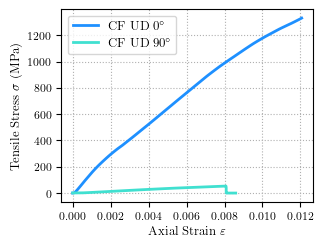

Tensile Modulus of CF UD 0: 123.57 GPa, R-squared: 0.9965
Tensile Modulus of CF UD 90: 7.86 GPa, R-squared: 1.0000


In [13]:
fig, ax = plt.subplots(figsize=(3.25,2.5))

ax.plot(df_tensile_0['strain'], df_tensile_0['stress'], linewidth=2, color='dodgerblue', label=r'CF UD 0$^\circ$')
ax.plot(df_tensile_90['strain'], df_tensile_90['stress'], linewidth=2, color='turquoise', label=r'CF UD 90$^\circ$')

ax.set_xlabel(r'Axial Strain $\varepsilon$')
ax.set_ylabel(r'Tensile Stress $\sigma$ (MPa)')
ax.grid(True, linestyle=':')
ax.legend()

fig.savefig('tensile_stress_strain.pdf', format='pdf', bbox_inches='tight')
plt.show()

modulus_0, r2_0 = calculate_modulus(df_tensile_0, 0.001, 0.003)
modulus_90, r2_90 = calculate_modulus(df_tensile_90, 0.001, 0.003)

print(f"Tensile Modulus of CF UD 0: {modulus_0:.2f} GPa, R-squared: {r2_0:.4f}")
print(f"Tensile Modulus of CF UD 90: {modulus_90:.2f} GPa, R-squared: {r2_90:.4f}")

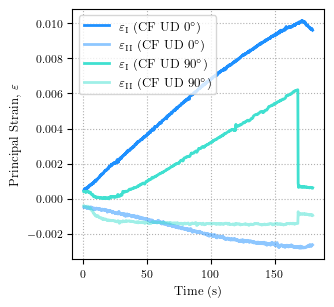

Poisson's Ratio of CF UD 0: 0.2582, R-squared: 0.9872
Poisson's Ratio of CF UD 90: 0.0223, R-squared: 0.5485


In [21]:
fig, ax = plt.subplots(figsize=(3.25,3.25))

ax.plot(df_tensile_0_dic['time'], df_tensile_0_dic['strain_major'], color='dodgerblue', linewidth=2, label=r'$\varepsilon_\mathrm{I}$ (CF UD 0$^\circ$)')
ax.plot(df_tensile_0_dic['time'], df_tensile_0_dic['strain_minor'], color='dodgerblue', linewidth=2, alpha=0.5, label=r'$\varepsilon_\mathrm{II}$ (CF UD 0$^\circ$)')

ax.plot(df_tensile_90_dic['time'], df_tensile_90_dic['strain_major'], color='turquoise', linewidth=2, label=r'$\varepsilon_\mathrm{I}$ (CF UD 90$^\circ$)')
ax.plot(df_tensile_90_dic['time'], df_tensile_90_dic['strain_minor'], color='turquoise', linewidth=2, alpha=0.5, label=r'$\varepsilon_\mathrm{II}$ (CF UD 90$^\circ$)')

ax.set_xlabel('Time (s)')
ax.set_ylabel(r'Principal Strain, $\varepsilon$')
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('tensile_strain_time.pdf', format='pdf', bbox_inches='tight')
plt.show()

poisson_0, r2_0 = calculate_poisson(df_tensile_0_dic, 50, 150)
poisson_90, r2_90 = calculate_poisson(df_tensile_90_dic, 50, 150)

print(f"Poisson's Ratio of CF UD 0: {poisson_0:.4f}, R-squared: {r2_0:.4f}")
print(f"Poisson's Ratio of CF UD 90: {poisson_90:.4f}, R-squared: {r2_90:.4f}")

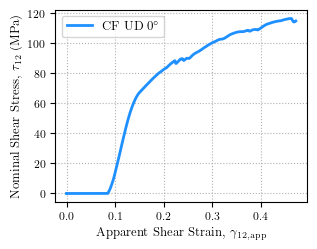

Shear Modulus of CF UD 0: 1.30 GPa, R-squared: 0.9989


In [15]:
fig, ax = plt.subplots(figsize=(3.25,2.5))

ax.plot(df_shear_0['strain'], df_shear_0['stress'], linewidth=2, color='dodgerblue', label=r'CF UD 0$^\circ$')

ax.set_xlabel(r'Apparent Shear Strain, $\gamma_{12,\mathrm{app}}$')
ax.set_ylabel(r'Nominal Shear Stress, $\tau_{12}$ (MPa)')
ax.grid(True, linestyle=':')
ax.legend()

fig.savefig('shear_stress_strain.pdf', format='pdf', bbox_inches='tight')
plt.show()

modulus_0, r2_0 = calculate_modulus(df_shear_0, 0.09, 0.13)

print(f"Shear Modulus of CF UD 0: {modulus_0:.2f} GPa, R-squared: {r2_0:.4f}")

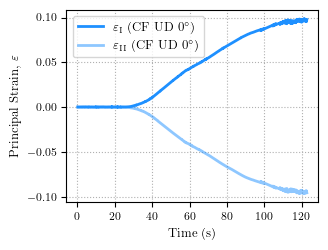

In [19]:
fig, ax = plt.subplots(figsize=(3.25,2.5))

ax.plot(df_shear_0_dic['time'], df_shear_0_dic['strain_major'], color='dodgerblue', linewidth=2, label=r'$\varepsilon_\mathrm{I}$ (CF UD 0$^\circ$)')
ax.plot(df_shear_0_dic['time'], df_shear_0_dic['strain_minor'], color='dodgerblue', linewidth=2, alpha=0.5, label=r'$\varepsilon_\mathrm{II}$ (CF UD 0$^\circ$)')

ax.set_xlabel('Time (s)')
ax.set_ylabel(r'Principal Strain, $\varepsilon$')
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('shear_strain_time.pdf', format='pdf', bbox_inches='tight')
plt.show()